# E-commerce Data Analysis

This notebook covers the data cleaning, statistical analysis, visualization, and predictive modeling for the scraped book data.

## Setup
Install necessary dependencies.

In [28]:
!pip install -r requirements.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import ipywidgets as widgets
from IPython.display import display

%matplotlib inline

## 0. Data Extraction

In [30]:
# Run the scraper to generate books_raw.csv
# !python scraper.py

## 1. Data Cleaning & Preprocessing

In [31]:
# Load data

df = pd.read_csv('books_raw.csv')
display(df.head())

,Title,Price,Rating,Category,Availability
0,A Light in the Attic,£51.77,Three,Poetry,In stock (22 available)
1,Tipping the Velvet,£53.74,One,Historical Fiction,In stock (20 available)
2,Soumission,£50.10,One,Fiction,In stock (20 available)
3,Sharp Objects,£47.82,Four,Mystery,In stock (20 available)
4,Sapiens: A Brief History of Humankind,£54.23,Five,History,In stock (20 available)


In [32]:
# Initial inspection
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Title         100 non-null    object
 1   Price         100 non-null    object
 2   Rating        100 non-null    object
 3   Category      100 non-null    object
 4   Availability  100 non-null    object
dtypes: object(5)
memory usage: 4.0+ KB


In [33]:
# Data Cleaning Functions

def clean_price(price_str):
    if isinstance(price_str, str):
        return float(price_str.replace('£', ''))
    return price_str

rating_map = {
    'One': 1,
    'Two': 2,
    'Three': 3,
    'Four': 4,
    'Five': 5
}

def clean_rating(rating_str):
    return rating_map.get(rating_str, 0)

def clean_availability(avail_str):
    return 'In stock' in str(avail_str)


In [34]:
# Apply Cleaning
df['Price_Cleaned'] = df['Price'].apply(clean_price)
df['Rating_Num'] = df['Rating'].apply(clean_rating)
df['In_Stock'] = df['Availability'].apply(clean_availability)

# Check for nulls and duplicates
print('Before Cleaning')
print(f"Missing values:\n{df.isnull().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")

# Drop duplicates if any
df = df.drop_duplicates()

# Derive Price Category
def categorize_price(price):
    if price < 20:
        return 'Budget'
    elif 20 <= price <= 40:
        return 'Mid-range'
    else:
        return 'Premium'

df['Price_Category'] = df['Price_Cleaned'].apply(categorize_price)
print('After Cleaning:')
df.head()

Before Cleaning
Missing values:
Title            0
Price            0
Rating           0
Category         0
Availability     0
Price_Cleaned    0
Rating_Num       0
In_Stock         0
dtype: int64
Duplicates: 0
After Cleaning:


,Title,Price,Rating,Category,Availability,Price_Cleaned,Rating_Num,In_Stock,Price_Category
0,A Light in the Attic,£51.77,Three,Poetry,In stock (22 available),51.77,3,True,Premium
1,Tipping the Velvet,£53.74,One,Historical Fiction,In stock (20 available),53.74,1,True,Premium
2,Soumission,£50.10,One,Fiction,In stock (20 available),50.10,1,True,Premium
3,Sharp Objects,£47.82,Four,Mystery,In stock (20 available),47.82,4,True,Premium
4,Sapiens: A Brief History of Humankind,£54.23,Five,History,In stock (20 available),54.23,5,True,Premium


In [35]:
# Save cleaned data
df.to_csv('books_cleaned.csv', index=False)
print("Cleaned data saved to books_cleaned.csv")

Cleaned data saved to books_cleaned.csv


## 2. Statistical Analysis

In [36]:
# Descriptive Stats
print("Price Statistics:")
print(df['Price_Cleaned'].describe())





Price Statistics:
count    100.000000
mean      34.560700
std       14.638531
min       10.160000
25%       19.897500
50%       34.775000
75%       47.967500
max       58.110000
Name: Price_Cleaned, dtype: float64


In [37]:
# Mode
print(f"Mode Price: {df['Price_Cleaned'].mode()[0]}")

# Range
print(f"Price Range: {df['Price_Cleaned'].max()} - {df['Price_Cleaned'].min()}")

Mode Price: 44.18
Price Range: 58.11 - 10.16


In [38]:

# Group Statistics (Avg Price by Category - Top 5)
top_categories = df['Category'].value_counts().head(5).index
df_top5 = df[df['Category'].isin(top_categories)]

print("\nAverage Price by Top 5 Category:")
print(df_top5.groupby('Category')['Price_Cleaned'].mean())


Average Price by Top 5 Category:
Category
Default           26.847778
Fiction           43.872000
Nonfiction        32.482500
Poetry            36.238571
Sequential Art    31.906429
Name: Price_Cleaned, dtype: float64


In [39]:
rating_counts = df['Rating_Num'].value_counts().sort_index(ascending=False)
rating_dist_df = pd.DataFrame({'Rating': rating_counts.index, 'Frequency': rating_counts.values})

print("Rating Frequency Distribution:")
display(rating_dist_df)

Rating Frequency Distribution:


,Rating,Frequency
0,5,19
1,4,18
2,3,22
3,2,19
4,1,22


In [40]:
# Inferential Statistics

# Outlier Detection (IQR)
Q1 = df['Price_Cleaned'].quantile(0.25)
Q3 = df['Price_Cleaned'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Price_Cleaned'] < (Q1 - 1.5 * IQR)) | (df['Price_Cleaned'] > (Q3 + 1.5 * IQR))]
print(f"Number of price outliers: {len(outliers)}")

# Correlation
corr, p_value = stats.pearsonr(df['Price_Cleaned'], df['Rating_Num'])
print(f"Pearson Correlation (Price vs Rating): {corr:.4f}, p-value: {p_value:.4f}")


Number of price outliers: 0
Pearson Correlation (Price vs Rating): -0.1217, p-value: 0.2276


In [41]:
# Hypothesis Testing
# Fiction vs Non-Fiction
# Assuming we can classify categories. For now, let's use two prominent categories if available,
# or just two random large categories to demonstrate the t-test.
# Let's check unique categories first.
print(df['Category'].unique())

['Poetry' 'Historical Fiction' 'Fiction' 'Mystery' 'History' 'Young Adult'
 'Business' 'Default' 'Sequential Art' 'Music' 'Science Fiction'
 'Politics' 'Travel' 'Thriller' 'Food and Drink' 'Romance' 'Childrens'
 'Nonfiction' 'Art' 'Spirituality' 'Philosophy' 'New Adult' 'Contemporary'
 'Fantasy' 'Add a comment' 'Science' 'Health' 'Horror' 'Self Help']


In [42]:
# Hypothesis Testing: Fiction vs Non-Fiction
print("\n--- Hypothesis Testing: Fiction vs Non-Fiction ---")

# 1. Group categories into 'Fiction' and 'Non-Fiction'
# We'll assume any category containing the word 'fiction' is Fiction.
# Remove rows where Category is missing
df = df.dropna(subset=['Category'])
is_fiction = df['Category'].str.contains('fiction', case=False)

fiction_prices = df[is_fiction_mask]['Price_Cleaned']
non_fiction_prices = df[~is_fiction_mask]['Price_Cleaned']

print(f"Fiction Books Count: {len(fiction_prices)}, Average Price: £{fiction_prices.mean():.2f}")
print(f"Non-Fiction Books Count: {len(non_fiction_prices)}, Average Price: £{non_fiction_prices.mean():.2f}")

# 2. Perform independent t-test
# Using equal_var=False (Welch's t-test) as variances might differ between the two groups
t_stat, p_value = stats.ttest_ind(fiction_prices, non_fiction_prices, equal_var=False)

# 3. Report t-statistic, p-value, and conclusion (alpha = 0.05)
alpha = 0.05

print(f"\nt-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

print("\nConclusion:")
if p_value < alpha:
    print(f"Reject the null hypothesis (α = {alpha}).")
    print("There is a statistically significant difference in the average prices between Fiction and Non-Fiction books.")
else:
    print(f"Fail to reject the null hypothesis (α = {alpha}).")
    print("There is no statistically significant difference in the average prices between Fiction and Non-Fiction books.")


--- Hypothesis Testing: Fiction vs Non-Fiction ---
Fiction Books Count: 20, Average Price: £36.81
Non-Fiction Books Count: 80, Average Price: £34.00

t-statistic: 0.8394
p-value: 0.4073

Conclusion:
Fail to reject the null hypothesis (α = 0.05).
There is no statistically significant difference in the average prices between Fiction and Non-Fiction books.


## 3. Data Visualization (Plotly & Interactive Dashboard)

In [43]:
# Histogram: Price Distribution
fig_hist = px.histogram(df, x='Price_Cleaned', nbins=20, title='Price Distribution',
                        labels={'Price_Cleaned': 'Price (£)'})
fig_hist.add_vline(x=df['Price_Cleaned'].mean(), line_dash="dash", line_color="red", annotation_text="Mean")
fig_hist.show()

In [44]:
# Box Plot: Price by Category (Top 5)
fig_box = px.box(df_top5, x='Category', y='Price_Cleaned', title='Price Distribution by Category (Top 5)')
fig_box.show()

In [45]:
# Scatter Plot: Price vs Rating
fig_scatter = px.scatter(df, x='Rating_Num', y='Price_Cleaned', trendline="ols",
                         title='Price vs Rating', hover_data=['Title', 'Category'])
fig_scatter.show()

/tmp/ipython-input-296/3826381236.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




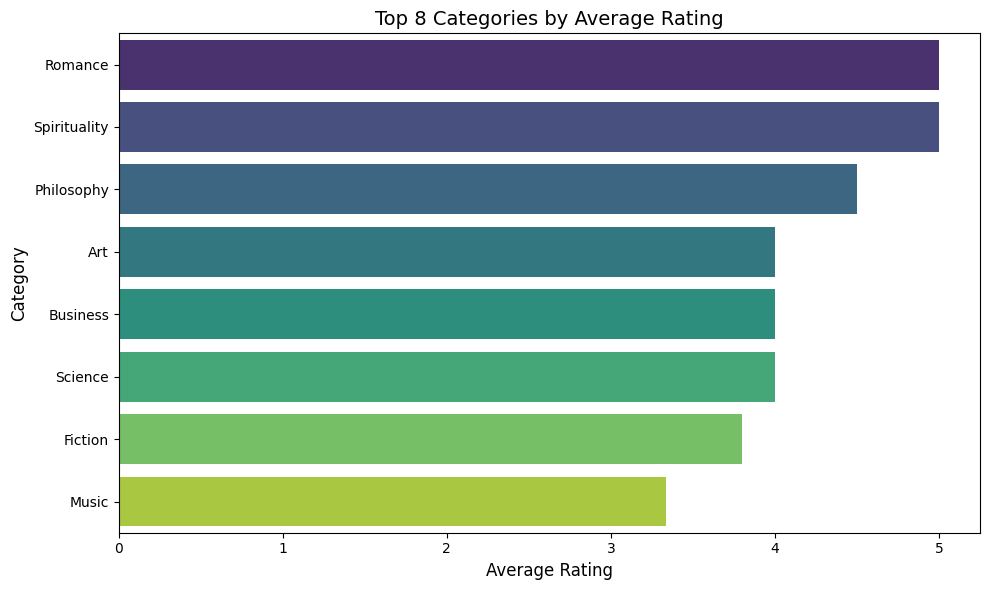

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Group by category, find the mean of the ratings, and grab the highest 8
# Note: Replace 'Rating' with your actual column name if it is slightly different (e.g., 'User_Rating')
top_8_categories = df.groupby('Category')['Rating_Num'].mean().nlargest(8).reset_index()

# 2. Set the size of the canvas
plt.figure(figsize=(10, 6))

# 3. Create a horizontal bar chart using Seaborn for a polished look
sns.barplot(data=top_8_categories, x='Rating_Num', y='Category', palette='viridis')

# 4. Add clear titles and labels
plt.title('Top 8 Categories by Average Rating', fontsize=14)
plt.xlabel('Average Rating', fontsize=12)
plt.ylabel('Category', fontsize=12)

# 5. Adjust layout and display
plt.tight_layout()
plt.show()

## 4. Predictive Analysis

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd

# 1. Prepare Features (X) and Target (y)
# We use pd.get_dummies to convert 'Category' into multiple columns of 0s and 1s
X = pd.get_dummies(df[['Rating_Num', 'Category']], drop_first=True)
y = df['Price_Cleaned']

# 2. Split data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Build and Train the Model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Make Predictions and Evaluate
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): £{mae:.2f}")

# 5. Interpretation: Identify stronger influence
# We look at the absolute value of the coefficients
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
top_features = coefficients.sort_values(by='Abs_Coefficient', ascending=False)

print("\nTop 5 Influential Features on Price:")
print(top_features.head(5))

R² Score: -0.4555
Mean Absolute Error (MAE): £12.69

Top 5 Influential Features on Price:
                        Feature  Coefficient  Abs_Coefficient
3            Category_Childrens    27.010674        27.010674
10  Category_Historical Fiction    24.092022        24.092022
9               Category_Health    21.949326        21.949326
1                  Category_Art    18.352978        18.352978
7              Category_Fiction    17.790247        17.790247
